# 07 — Figuras finales (regeneración con estilo consistente)

Regenera **solo las figuras que cambian** de la revisión crítica, con:
- Tipografía **Times New Roman** y exportación a **300 dpi**.
- **Paleta única** y rampa ordinal fija para las clases de gravedad (BAJA→CRÍTICA).
- Versiones **solo-ORIGINAL** (sin datos imputados) de Fig 5, 11 y 12, como control de robustez.
- Figuras temporales **agregadas** (sin saturación de barras por año).
- Figura 14 con **eje 0–1** (sin truncamiento engañoso).

No reentrena ni recalcula el modelo. Solo lee el dataset final y dibuja.
Cada celda está **protegida**: si falta una columna, avisa y continúa.


In [2]:
# CONFIGURACION
import warnings; warnings.filterwarnings("ignore")
import os
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ruta al dataset final. Idealmente uno que contenga: delitos, tipo_dato, gravedad,
# anio, mes, dia_semana, hora, codigo_distrito, tipo_arma.
# (Si estan en archivos distintos, unelos antes en un solo DataFrame.)
NOMBRE_CSV = "mdi_detenidosaprehendidos_guayaquil_2019_2025_con_delitos_y_tipo_dato.csv"
RUTA = str(Path(r"C:\Users\jhono\Downloads\Proyecto Titulacion\CSV") / NOMBRE_CSV)
SEP  = ";"           # separador del CSV
OUT  = "figuras_finales"
os.makedirs(OUT, exist_ok=True)

BASE = Path.cwd()
CANDIDATAS = [
    Path(RUTA),
    BASE / NOMBRE_CSV,
    BASE.parent / "CSV" / NOMBRE_CSV,
    Path(r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV") / NOMBRE_CSV,
    Path(r"C:\Users\jhono\Downloads\Proyecto Titulacion\CSV") / NOMBRE_CSV,
]
ruta_encontrada = next((p for p in CANDIDATAS if p.exists()), None)
if ruta_encontrada is None:
    raise FileNotFoundError(
        "No se encontro el CSV principal. Rutas probadas:\n" + "\n".join(str(p) for p in CANDIDATAS)
    )
RUTA = str(ruta_encontrada)

mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        110,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

AZULES = ["#1F4E79", "#2E75B6", "#9DC3E6", "#CFE2F3", "#7F7F7F"]
COLOR_GRAVEDAD = {"BAJA":"#FEE08B", "MEDIA":"#FDAE61", "ALTA":"#F46D43",
                  "CRITICA":"#D73027", "CRÍTICA":"#D73027"}
ORDEN_GRAVEDAD = ["BAJA","MEDIA","ALTA","CRITICA"]

def guardar(fig, nombre):
    ruta = os.path.join(OUT, nombre)
    fig.savefig(ruta)
    print("   guardada ->", ruta)
print("Configuracion lista. Carpeta de salida:", OUT)
print("CSV principal:", RUTA)

Configuracion lista. Carpeta de salida: figuras_finales
CSV principal: c:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_detenidosaprehendidos_guayaquil_2019_2025_con_delitos_y_tipo_dato.csv


In [5]:
# CARGA + DIAGNOSTICO
df = pd.read_csv(RUTA, sep=SEP, encoding="utf-8-sig", low_memory=False)
print("Registros:", f"{len(df):,}")
print("Columnas :", list(df.columns))
if "gravedad" in df.columns and pd.api.types.is_numeric_dtype(df["gravedad"]):
    MAPA = {0:"BAJA",1:"MEDIA",2:"ALTA",3:"CRITICA"}
    if df["gravedad"].max() <= 3:
        df["clase_gravedad"] = df["gravedad"].map(MAPA)
    else:
        df["clase_gravedad"] = pd.cut(df["gravedad"], bins=[-1,3,6,9,12],
                                      labels=["BAJA","MEDIA","ALTA","CRITICA"])
elif "clase_gravedad" not in df.columns and "gravedad" in df.columns:
    df["clase_gravedad"] = df["gravedad"].astype(str).str.upper()
print("\n¿tipo_dato?", "tipo_dato" in df.columns,
      "| ¿delitos?", "delitos" in df.columns,
      "| ¿clase_gravedad?", "clase_gravedad" in df.columns,
      "| ¿tipo_arma?", "tipo_arma" in df.columns)

Registros: 76,860
Columnas : ['Unnamed: 0', 'codigo_iccs', 'delitos', 'tipo_dato', 'tipo', 'estado civil', 'estatus_migratorio', 'edad', 'sexo', 'genero', 'nacionalidad', 'autoidentificacion_etnica', 'nivel_de_instruccion', 'condicion', 'movilizacion', 'tipo_arma', 'arma', 'fecha_detencion_aprehension', 'hora_detencion_aprehension', 'lugar', 'tipo_lugar', 'nombre_zona', 'nombre_subzona', 'codigo_distrito', 'nombre_distrito', 'codigo_circuito', 'nombre_circuito', 'codigo_subcircuito', 'nombre_subcircuito', 'codigo_provincia', 'nombre_provincia', 'codigo_canton', 'nombre_canton', 'codigo_parroquia', 'nombre_parroquia', 'presunta_infraccion', 'latitud', 'longitud', 'flag_coord']

¿tipo_dato? True | ¿delitos? True | ¿clase_gravedad? False | ¿tipo_arma? True


## Segundo dataset (features + gravedad)

Fig 2, 3, 11 y 12 necesitan `anio`, `mes`, `dia_semana` y `gravedad`, columnas que NO
estan en el CSV crudo cargado arriba. Estan en `mdi_train.csv` + `mdi_test.csv`
(el par usado en `generar_encoders.ipynb`). Ajusta las rutas si es necesario.


In [6]:
# CARGA DATASET 2 (features + gravedad) para Fig 2, 3, 11, 12
NOMBRE_TRAIN = "mdi_train.csv"
NOMBRE_TEST  = "mdi_test.csv"
BASE = Path.cwd()

def _resolver_ruta_csv(nombre_archivo):
    candidatas = [
        BASE / nombre_archivo,
        BASE.parent / "CSV" / nombre_archivo,
        Path(r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV") / nombre_archivo,
        Path(r"C:\Users\jhono\Downloads\Proyecto Titulacion\CSV") / nombre_archivo,
    ]
    return next((p for p in candidatas if p.exists()), None)

RUTA_TRAIN = _resolver_ruta_csv(NOMBRE_TRAIN)
RUTA_TEST  = _resolver_ruta_csv(NOMBRE_TEST)

df2 = None
try:
    if RUTA_TRAIN is None or RUTA_TEST is None:
        faltantes = []
        if RUTA_TRAIN is None:
            faltantes.append(NOMBRE_TRAIN)
        if RUTA_TEST is None:
            faltantes.append(NOMBRE_TEST)
        raise FileNotFoundError("No se encontraron: " + ", ".join(faltantes))

    _train = pd.read_csv(RUTA_TRAIN, sep=";", encoding="utf-8-sig", low_memory=False)
    _test  = pd.read_csv(RUTA_TEST,  sep=";", encoding="utf-8-sig", low_memory=False)
    df2 = pd.concat([_train, _test], ignore_index=True)
    print("df2 cargado:", f"{len(df2):,}", "registros |", list(df2.columns))
    print("RUTA_TRAIN:", str(RUTA_TRAIN))
    print("RUTA_TEST :", str(RUTA_TEST))
except Exception as e:
    print("No se pudo cargar df2:", repr(e))
    print("Fig 2, 3, 11 y 12 se omitiran. Verifica la ubicacion de mdi_train.csv y mdi_test.csv.")

if df2 is not None and "gravedad" in df2.columns and pd.api.types.is_numeric_dtype(df2["gravedad"]):
    MAPA = {0:"BAJA",1:"MEDIA",2:"ALTA",3:"CRITICA"}
    if df2["gravedad"].max() <= 3:
        df2["clase_gravedad"] = df2["gravedad"].map(MAPA)
    else:
        df2["clase_gravedad"] = pd.cut(df2["gravedad"], bins=[-1,3,6,9,12],
                                       labels=["BAJA","MEDIA","ALTA","CRITICA"])

df2 cargado: 76,860 registros | ['anio', 'mes', 'dia_semana', 'es_fin_de_semana', 'hora', 'codigo_distrito', 'codigo_circuito', 'codigo_subcircuito', 'freq_subcircuito', 'codigo_iccs', 'macro_lugar', 'flag_coord', 'gravedad']
RUTA_TRAIN: c:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_train.csv
RUTA_TEST : c:\Users\jhono\Downloads\Proyecto Titulación\CSV\mdi_test.csv


   guardada -> figuras_finales\fig05_top5_delitos.png


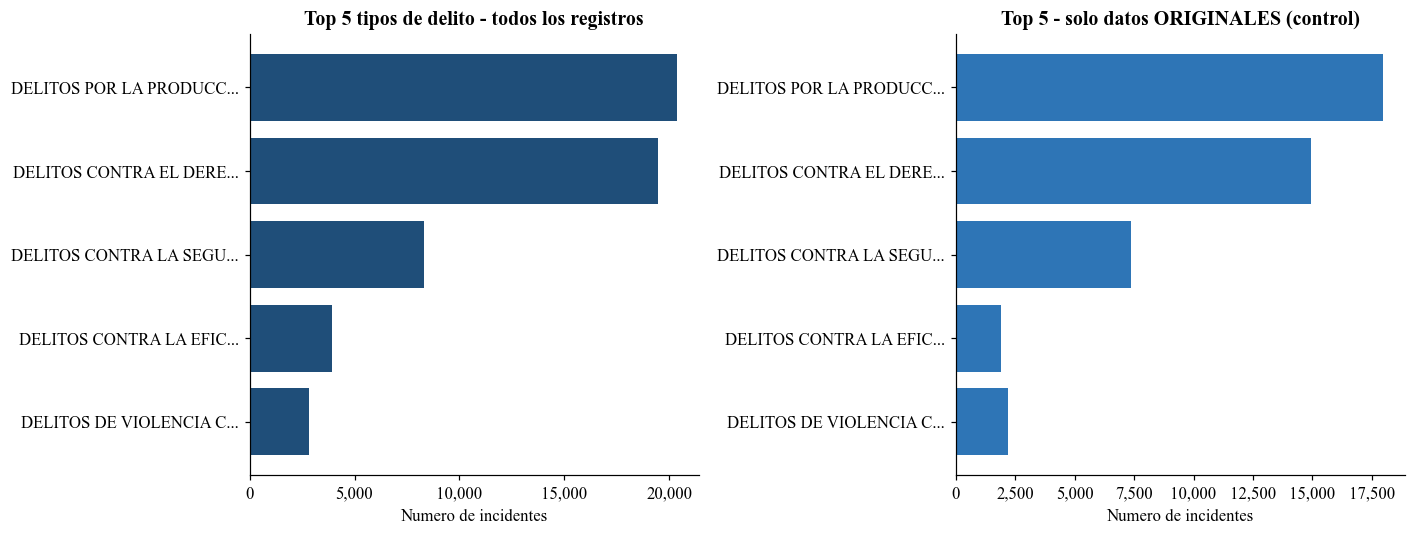


Proporcion del top 5 (robustez):
                                                     Todos %  Solo ORIGINAL %
delitos                                                                     
DELITOS POR LA PRODUCCIÓN O TRÁFICO ILÍCITO DE ...     26.5             32.1
DELITOS CONTRA EL DERECHO A LA PROPIEDAD               25.3             26.7
DELITOS CONTRA LA SEGURIDAD PÚBLICA                    10.8             13.1
DELITOS CONTRA LA EFICIENCIA DE LA ADMINISTRACI...      5.1              3.4
DELITOS DE VIOLENCIA CONTRA LA MUJER O MIEMBROS...      3.7              3.9


In [7]:
# FIG 5 - TOP 5 DELITOS: total + control solo-ORIGINAL
if "delitos" in df.columns:
    ETIQ = lambda s: (s[:22]+"...") if len(s) > 24 else s
    top5 = df["delitos"].value_counts().head(5)
    fig, axes = plt.subplots(1, 2, figsize=(13,5))
    t = df["delitos"].value_counts().head(5)
    axes[0].barh([ETIQ(x) for x in t.index][::-1], t.values[::-1], color=AZULES[0])
    axes[0].set_title("Top 5 tipos de delito - todos los registros")
    axes[0].set_xlabel("Numero de incidentes")
    if "tipo_dato" in df.columns:
        d_o = df[df["tipo_dato"].astype(str).str.upper()=="ORIGINAL"]
        t2 = d_o["delitos"].value_counts().reindex(top5.index)
        axes[1].barh([ETIQ(x) for x in t2.index][::-1], t2.values[::-1], color=AZULES[1])
        axes[1].set_title("Top 5 - solo datos ORIGINALES (control)")
        axes[1].set_xlabel("Numero de incidentes")
    else:
        axes[1].axis("off"); axes[1].text(0.5,0.5,"Sin columna tipo_dato",ha="center")
    for ax in axes:
        ax.xaxis.set_major_formatter(lambda x,_: f"{int(x):,}")
    plt.tight_layout(); guardar(fig, "fig05_top5_delitos.png"); plt.show()
    if "tipo_dato" in df.columns:
        comp = pd.DataFrame({
            "Todos %": (df["delitos"].value_counts(normalize=True)*100).head(5).round(1),
            "Solo ORIGINAL %": (d_o["delitos"].value_counts(normalize=True)*100).reindex(top5.index).round(1)})
        print("\nProporcion del top 5 (robustez):\n", comp)
else:
    print("No hay columna 'delitos' - omitida Fig 5.")

df2 no tiene 'tipo_dato' - se omite el control solo-ORIGINAL.
   guardada -> figuras_finales\fig11_clases_gravedad.png


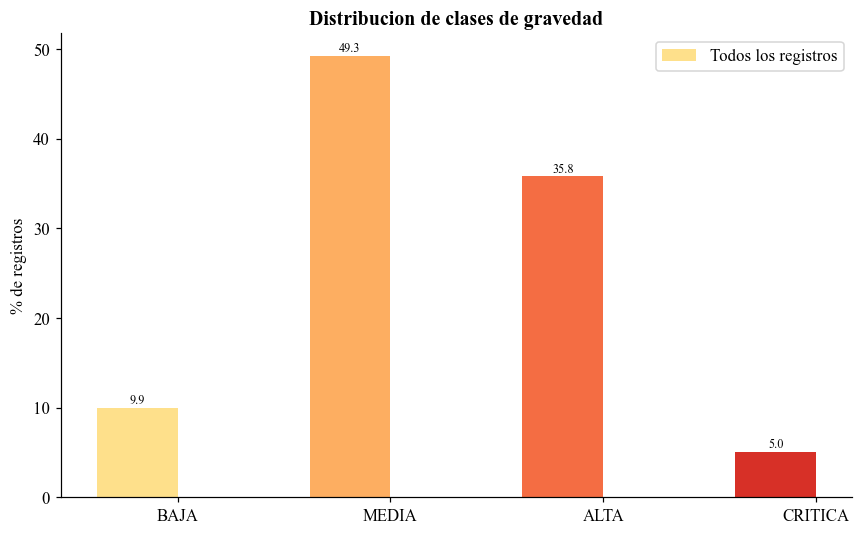

In [8]:
# FIG 11 - DISTRIBUCION DE CLASES: todos vs solo-ORIGINAL
# Usa df2 (tiene 'gravedad'/'clase_gravedad'). El control solo-ORIGINAL requiere
# 'tipo_dato' en df2; si no esta, se grafica solo la distribucion total.
if df2 is not None and "clase_gravedad" in df2.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    todos = df2["clase_gravedad"].value_counts(normalize=True).reindex(ORDEN_GRAVEDAD)*100
    x = np.arange(len(ORDEN_GRAVEDAD)); w = 0.38
    ax.bar(x-w/2, todos.values, w, label="Todos los registros",
           color=[COLOR_GRAVEDAD[g] for g in ORDEN_GRAVEDAD])
    if "tipo_dato" in df2.columns:
        d_o = df2[df2["tipo_dato"].astype(str).str.upper()=="ORIGINAL"]
        orig = d_o["clase_gravedad"].value_counts(normalize=True).reindex(ORDEN_GRAVEDAD)*100
        ax.bar(x+w/2, orig.values, w, label="Solo ORIGINAL",
               color=[COLOR_GRAVEDAD[g] for g in ORDEN_GRAVEDAD], hatch="//", alpha=0.7)
    else:
        print("df2 no tiene 'tipo_dato' - se omite el control solo-ORIGINAL.")
    ax.set_xticks(x); ax.set_xticklabels(ORDEN_GRAVEDAD)
    ax.set_ylabel("% de registros"); ax.set_title("Distribucion de clases de gravedad")
    ax.legend()
    for i,v in enumerate(todos.values):
        ax.text(x[i]-w/2, v+0.5, f"{v:.1f}", ha="center", fontsize=8)
    plt.tight_layout(); guardar(fig, "fig11_clases_gravedad.png"); plt.show()
else:
    print("df2 no disponible o sin 'clase_gravedad' - omitida Fig 11.")

   guardada -> figuras_finales\fig12_clases_por_anio.png


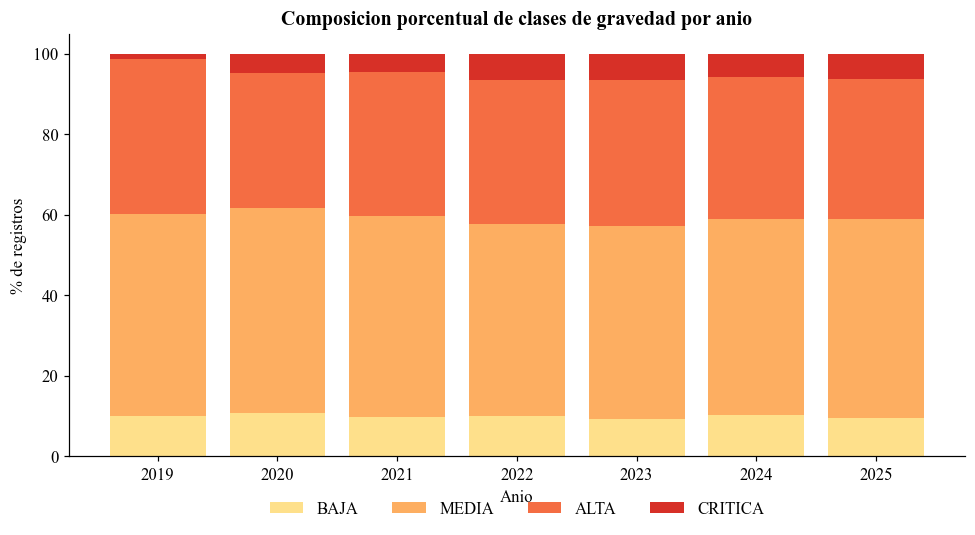

In [9]:
# FIG 12 - COMPOSICION DE CLASES POR ANIO (rampa ordinal)
if df2 is not None and "clase_gravedad" in df2.columns and "anio" in df2.columns:
    comp = (df2.groupby(["anio","clase_gravedad"]).size()
              .groupby(level=0, group_keys=False).apply(lambda s: s/s.sum()*100)
              .unstack().reindex(columns=ORDEN_GRAVEDAD))
    fig, ax = plt.subplots(figsize=(9,5))
    bottom = np.zeros(len(comp))
    for g in ORDEN_GRAVEDAD:
        ax.bar(comp.index.astype(str), comp[g].values, bottom=bottom,
               label=g, color=COLOR_GRAVEDAD[g])
        bottom += comp[g].values
    ax.set_ylabel("% de registros"); ax.set_xlabel("Anio")
    ax.set_title("Composicion porcentual de clases de gravedad por anio")
    ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5,-0.18), frameon=False)
    plt.tight_layout(); guardar(fig, "fig12_clases_por_anio.png"); plt.show()
else:
    print("df2 no disponible o faltan columnas para Fig 12.")

   guardada -> figuras_finales\fig02_estacional_mensual.png


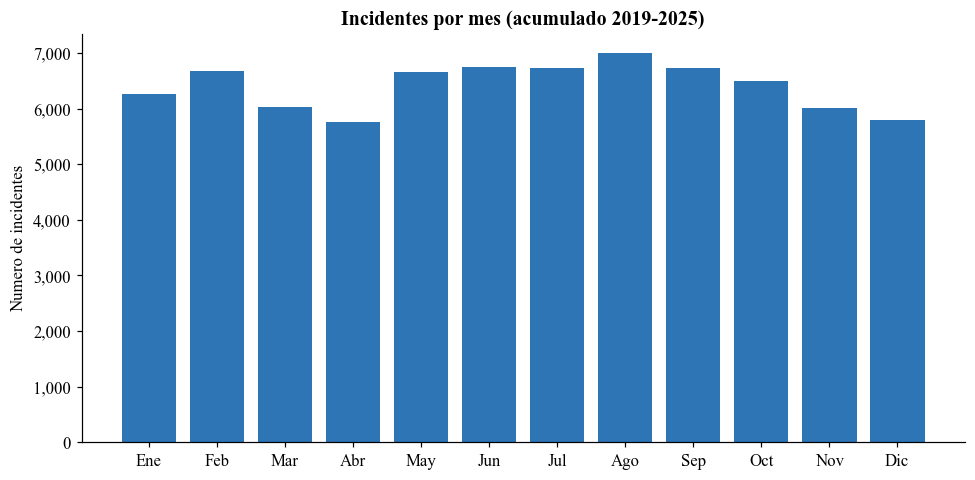

In [10]:
# FIG 2 - PERFIL ESTACIONAL MENSUAL (agregado)
if df2 is not None and "mes" in df2.columns:
    MESES = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
    pm = df2.groupby("mes").size().reindex(range(1,13))
    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.bar(MESES, pm.values, color=AZULES[1])
    ax.set_title("Incidentes por mes (acumulado 2019-2025)")
    ax.set_ylabel("Numero de incidentes")
    ax.yaxis.set_major_formatter(lambda x,_: f"{int(x):,}")
    plt.tight_layout(); guardar(fig, "fig02_estacional_mensual.png"); plt.show()
else:
    print("df2 no disponible o sin 'mes' - omitida Fig 2.")

   guardada -> figuras_finales\fig03_dia_semana.png


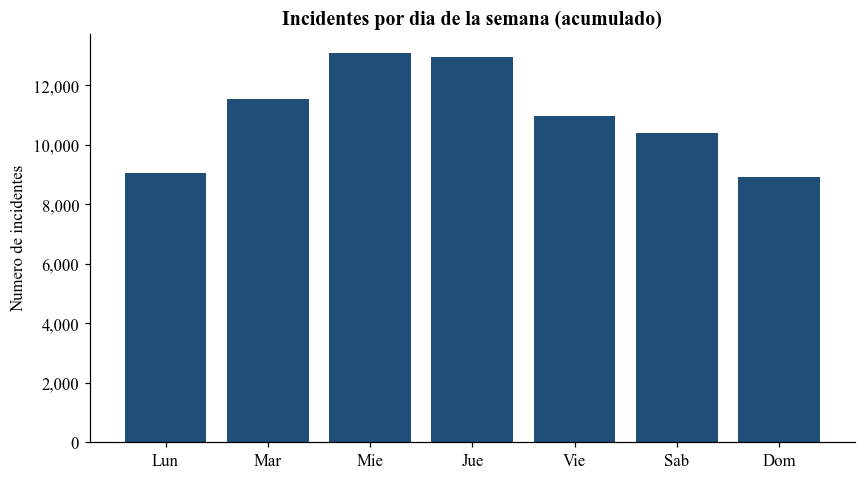

In [11]:
# FIG 3 - DIA DE LA SEMANA (agregado)
if df2 is not None and "dia_semana" in df2.columns:
    DIAS = ["Lun","Mar","Mie","Jue","Vie","Sab","Dom"]
    pds = df2.groupby("dia_semana").size().reindex(range(0,7))
    fig, ax = plt.subplots(figsize=(8,4.5))
    ax.bar(DIAS, pds.values, color=AZULES[0])
    ax.set_title("Incidentes por dia de la semana (acumulado)")
    ax.set_ylabel("Numero de incidentes")
    ax.yaxis.set_major_formatter(lambda x,_: f"{int(x):,}")
    plt.tight_layout(); guardar(fig, "fig03_dia_semana.png"); plt.show()
else:
    print("df2 no disponible o sin 'dia_semana' - omitida Fig 3.")

   guardada -> figuras_finales\fig07_distrito.png


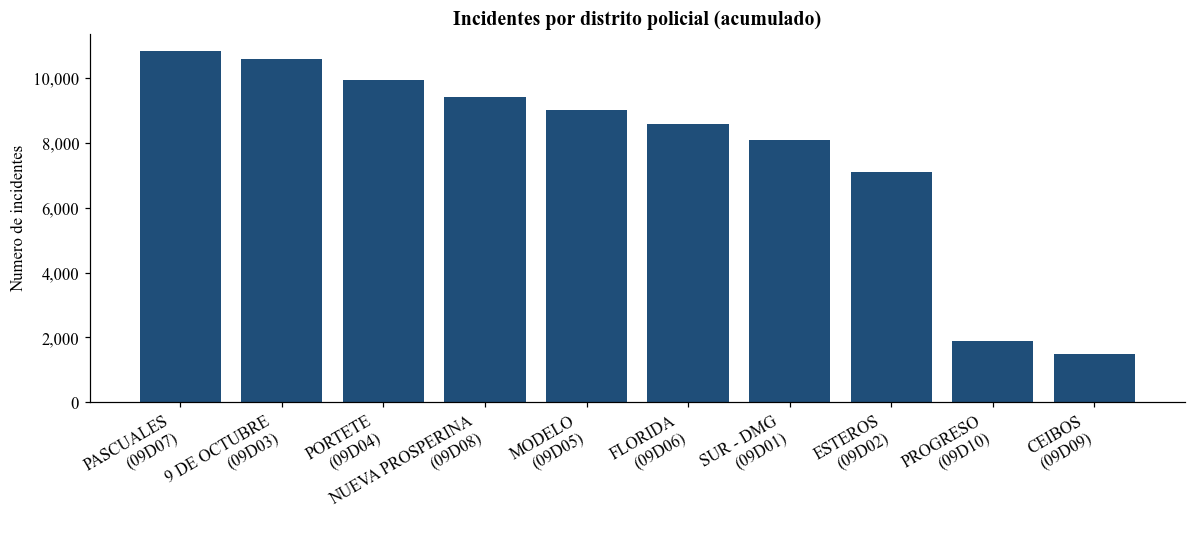

In [12]:
# FIG 7 - POR DISTRITO (usa nombre_distrito real del dataset)
if "codigo_distrito" in df.columns:
    if "nombre_distrito" in df.columns:
        # nombre + codigo, ordenado por frecuencia
        mapa_nombre = df.groupby("codigo_distrito")["nombre_distrito"].first()
        pdtto = df.groupby("codigo_distrito").size().sort_values(ascending=False)
        etiquetas = [f"{mapa_nombre[c]}\n({c})" for c in pdtto.index]
    else:
        pdtto = df.groupby("codigo_distrito").size().sort_values(ascending=False)
        etiquetas = [str(c) for c in pdtto.index]
        print("Aviso: no hay 'nombre_distrito'; se muestran solo codigos.")
    fig, ax = plt.subplots(figsize=(11,5))
    ax.bar(etiquetas, pdtto.values, color=AZULES[0])
    ax.set_title("Incidentes por distrito policial (acumulado)")
    ax.set_ylabel("Numero de incidentes")
    ax.yaxis.set_major_formatter(lambda x,_: f"{int(x):,}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); guardar(fig, "fig07_distrito.png"); plt.show()
else:
    print("No hay 'codigo_distrito' - omitida Fig 7.")

   guardada -> figuras_finales\fig09_tipo_arma.png


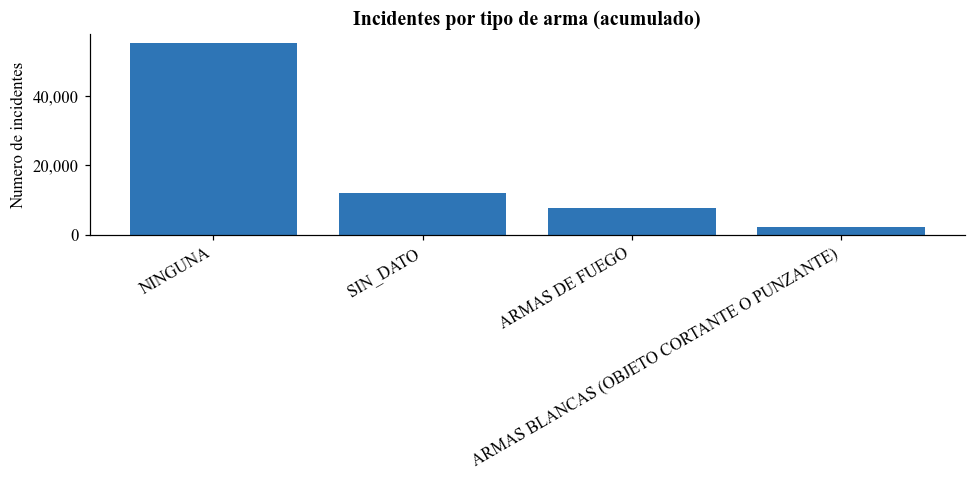

In [13]:
# FIG 9 - TIPO DE ARMA (simplificado)
if "tipo_arma" in df.columns:
    pa = df["tipo_arma"].astype(str).str.upper().value_counts().head(6)
    fig, ax = plt.subplots(figsize=(9,4.5))
    ax.bar(pa.index, pa.values, color=AZULES[1])
    ax.set_title("Incidentes por tipo de arma (acumulado)")
    ax.set_ylabel("Numero de incidentes")
    ax.yaxis.set_major_formatter(lambda x,_: f"{int(x):,}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); guardar(fig, "fig09_tipo_arma.png"); plt.show()
else:
    print("No hay 'tipo_arma' - omitida Fig 9.")

   guardada -> figuras_finales\fig14_metricas.png


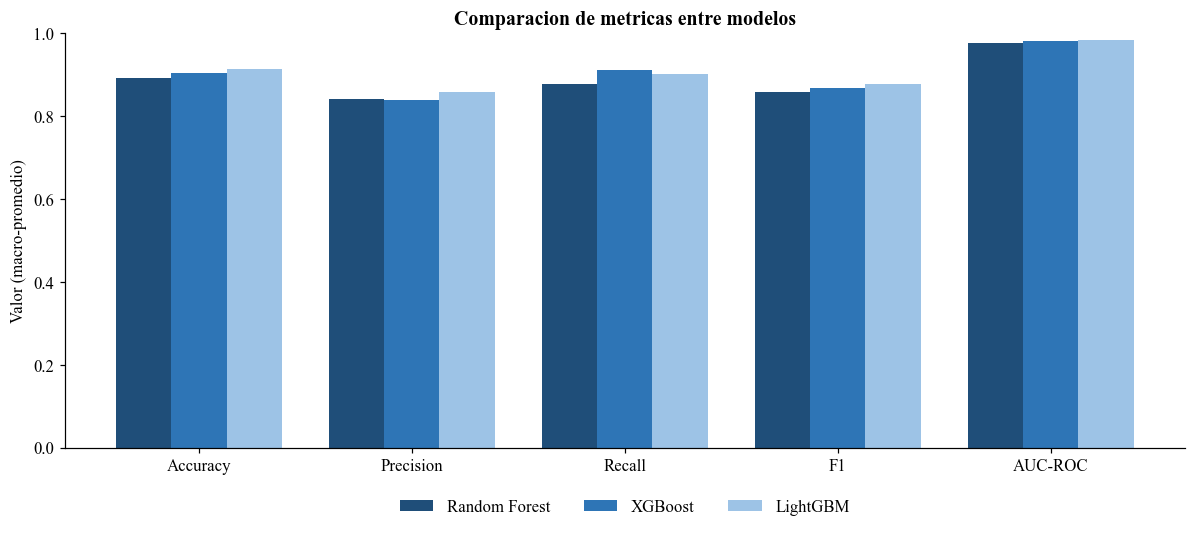

Eje 0-1: las diferencias se ven pequenas porque lo son; el detalle va en la Tabla 1.


In [14]:
# FIG 14 - COMPARACION DE METRICAS con eje 0-1 (sin truncar)
metricas = ["Accuracy","Precision","Recall","F1","AUC-ROC"]
datos = {
    "Random Forest": [0.8914,0.8406,0.8769,0.8574,0.9768],
    "XGBoost":       [0.9053,0.8402,0.9108,0.8687,0.9812],
    "LightGBM":      [0.9148,0.8593,0.9023,0.8784,0.9850],
}
x = np.arange(len(metricas)); w = 0.26
fig, ax = plt.subplots(figsize=(11,5))
for i,(modelo,vals) in enumerate(datos.items()):
    ax.bar(x+(i-1)*w, vals, w, label=modelo, color=AZULES[i])
ax.set_ylim(0,1)
ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylabel("Valor (macro-promedio)")
ax.set_title("Comparacion de metricas entre modelos")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5,-0.2), frameon=False)
plt.tight_layout(); guardar(fig, "fig14_metricas.png"); plt.show()
print("Eje 0-1: las diferencias se ven pequenas porque lo son; el detalle va en la Tabla 1.")

In [15]:
# RESUMEN
print("Figuras generadas en:", os.path.abspath(OUT))
for f in sorted(os.listdir(OUT)):
    print("  -", f)

Figuras generadas en: c:\Users\jhono\Downloads\Proyecto Titulación\CSV\figuras_finales
  - fig02_estacional_mensual.png
  - fig03_dia_semana.png
  - fig05_top5_delitos.png
  - fig07_distrito.png
  - fig09_tipo_arma.png
  - fig11_clases_gravedad.png
  - fig12_clases_por_anio.png
  - fig14_metricas.png
